# Workshop-1 : Adding Sunglasses to Your Passport Photo Using OpenCV


## Name : Keerthivasan K S
## Reg. No: 212224230120



In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

This cell reads the face image `Workshop-1(Photo).jpg` into a variable `faceImage` using OpenCV. It then displays the image using Matplotlib, converting the color channels from BGR (OpenCV default) to RGB (Matplotlib default) using `[:,:,::-1]`.

Text(0.5, 1.0, 'Face')

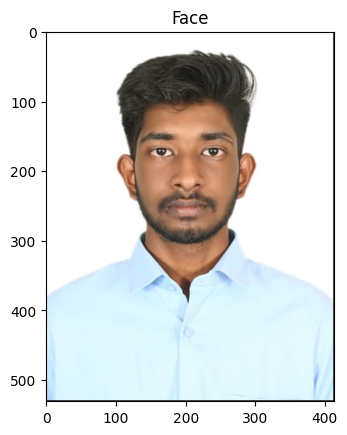

In [ ]:
faceImage = cv2.imread("Workshop-1(Photo).jpg")
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")

This cell prints the shape (dimensions) of the `faceImage` array, which typically represents (height, width, number of channels).

In [ ]:
faceImage.shape

(531, 413, 3)

This cell re-checks and prints the shape of the `faceImage`, confirming its dimensions.

In [ ]:
#resized_faceImage.shape
faceImage.shape

(531, 413, 3)

This cell loads a sunglass image named `Glass.png`. The `-1` argument for `cv2.imread` ensures that the image is loaded as is, including any alpha (transparency) channel. The image is then displayed.

Text(0.5, 1.0, 'glassPNG')

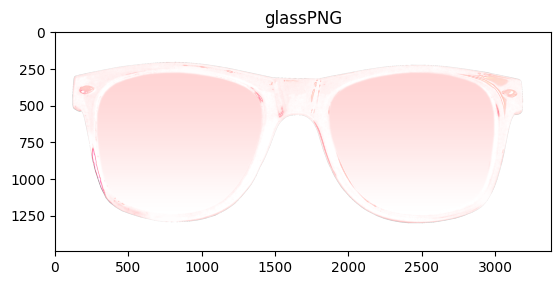

In [ ]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread("Glass.png",-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

Here, the `glassPNG` image is resized to a specific dimension (190 pixels wide, 50 pixels high) using `cv2.resize`. The new dimensions are then printed.

In [ ]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


This cell separates the color channels (BGR) and the alpha (transparency) channel from the `glassPNG` image. `glassBGR` holds the color information, and `glassMask1` holds the single-channel alpha mask.

In [ ]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

This cell visually displays the separated components of the sunglass image: the BGR color channels and the grayscale alpha mask. This helps in understanding how the transparency is stored.

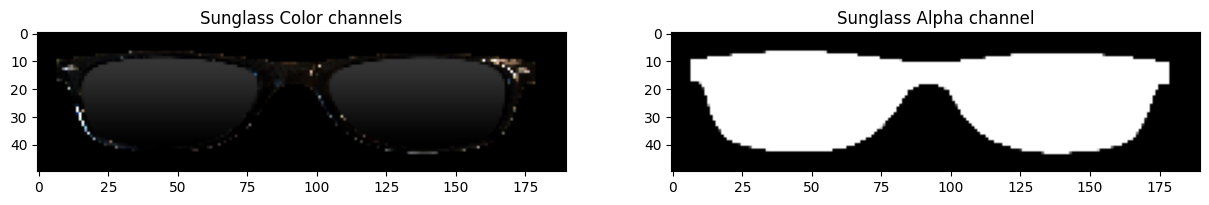

In [ ]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

This cell demonstrates a naive method of overlaying the sunglasses. It makes a copy of the face image and directly replaces a rectangular region (corresponding to the eyes) with the `glassBGR` image. This method does not account for transparency.

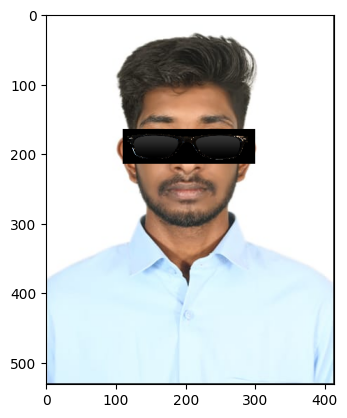

In [ ]:
# Make a copy
#faceWithGlassesNaive = resized_faceImage.copy()
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region with the sunglass image
faceWithGlassesNaive[165:215,110:300]=glassBGR

plt.imshow(faceWithGlassesNaive[...,::-1])

This cell implements a more sophisticated image augmentation using arithmetic operations to handle transparency. It involves:
1.  Creating a 3-channel mask from the single-channel `glassMask1`.
2.  Normalizing the mask values to be between 0 and 1.
3.  Extracting the eye region from the face image.
4.  Using the mask to *remove* the eye region (`maskedEye`).
5.  Using the mask to *extract* the sunglass region (`maskedGlass`).
6.  Combining the masked eye and sunglass regions (`eyeRoiFinal`) to create the augmented eye area.
Intermediate results are displayed to show each step of the masking process.

Text(0.5, 1.0, 'Augmented Eye and Sunglass')

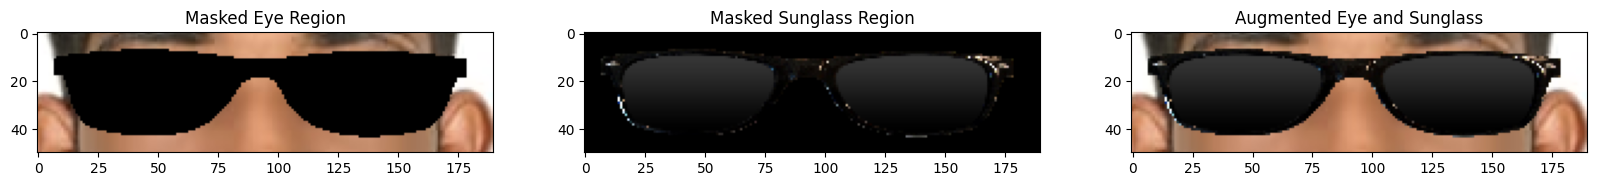

In [ ]:
# Make the dimensions of the mask same as the input image.
# Since Face Image is a 3-channel image, we create a 3 channel image for the mask
glassMask = cv2.merge((glassMask1,glassMask1,glassMask1))

# Make the values [0,1] since we are using arithmetic operations
glassMask = np.uint8(glassMask/255)

# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Get the eye region from the face image
eyeROI= faceWithGlassesArithmetic[151:201,110:300]

# Use the mask to create the masked eye region
maskedEye = cv2.multiply(eyeROI,(1-  glassMask ))

# Use the mask to create the masked sunglass region
maskedGlass = cv2.multiply(glassBGR,glassMask)

# Combine the Sunglass in the Eye Region to get the augmented image
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Display the intermediate results
plt.figure(figsize=[20,20])
plt.subplot(131);plt.imshow(maskedEye[...,::-1]);plt.title("Masked Eye Region")
plt.subplot(132);plt.imshow(maskedGlass[...,::-1]);plt.title("Masked Sunglass Region")
plt.subplot(133);plt.imshow(eyeRoiFinal[...,::-1]);plt.title("Augmented Eye and Sunglass")

Finally, this cell replaces the original eye region in the `faceWithGlassesArithmetic` image with the `eyeRoiFinal` (the augmented eye region with sunglasses). It then displays both the original face image and the face with arithmetically augmented sunglasses for comparison.

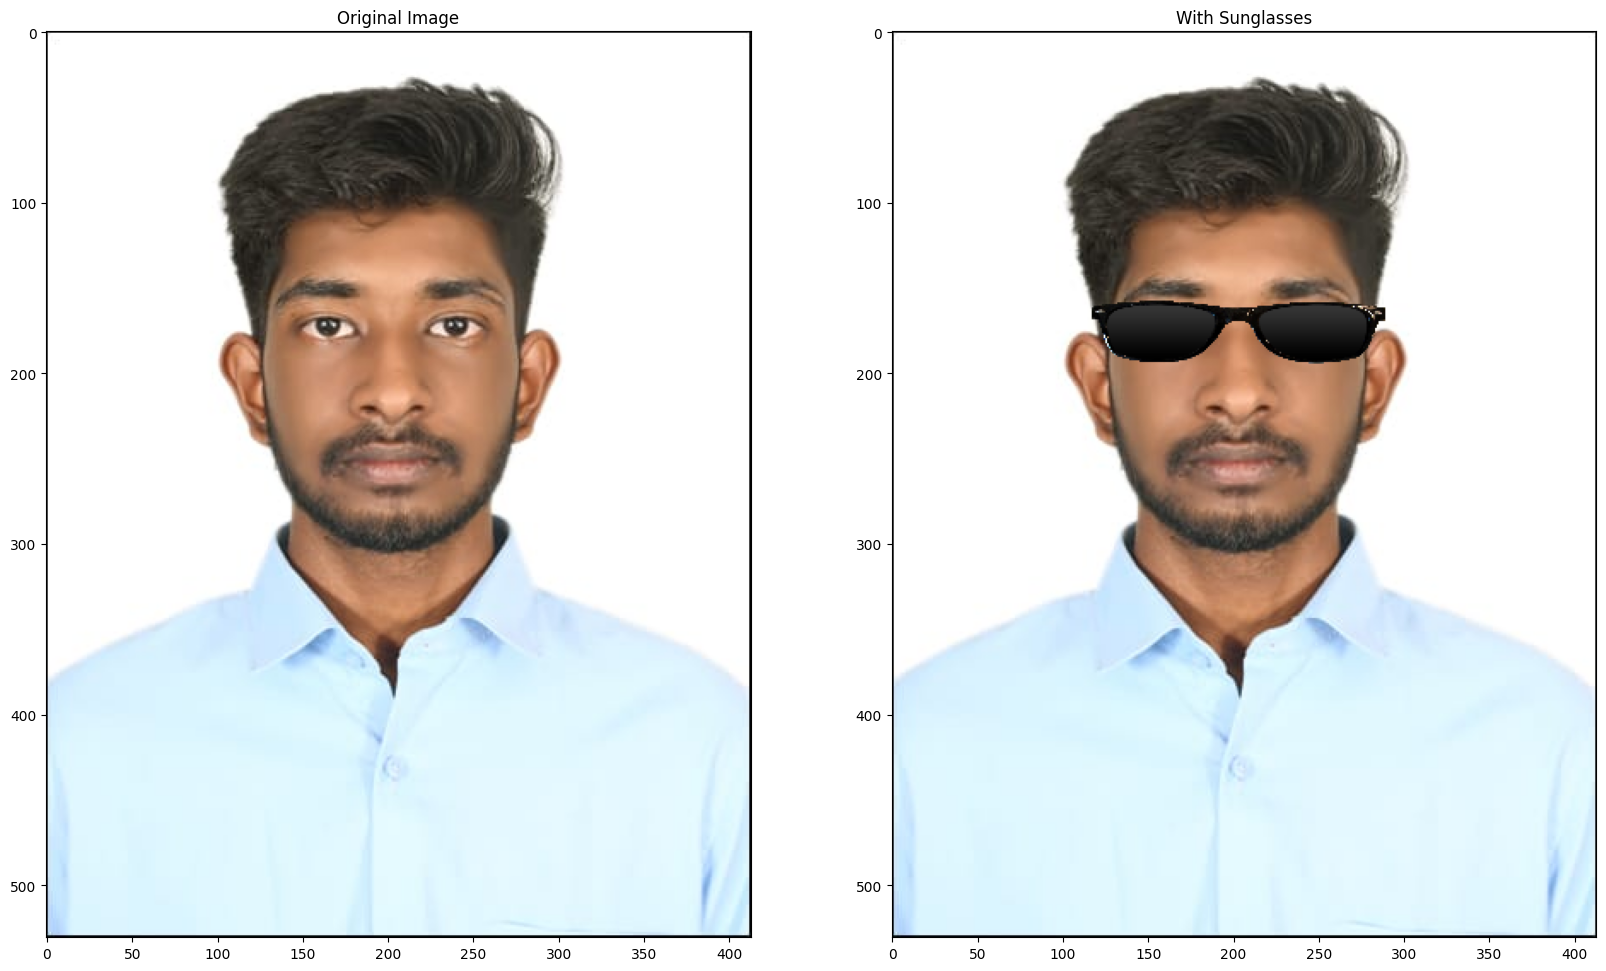

In [ ]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[151:201,110:300]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");

This cell is another attempt at the naive overlay method. It copies the original face image and directly replaces a specific eye region with the `glassBGR` image. This is similar to a previous naive attempt and does not handle transparency.

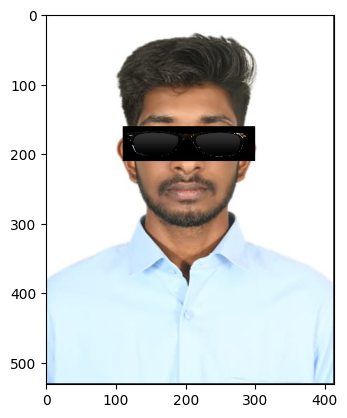

In [ ]:
# Make a copy
#faceWithGlassesNaive = resized_faceImage.copy()
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region with the sunglass image
faceWithGlassesNaive[151:201,110:300]=glassBGR

plt.imshow(faceWithGlassesNaive[...,::-1])